# 02 — Zero sound on real ³He parameters

**What this shows.** The model of notebook 01 confronted with data. The Landau parameters of liquid ³He from 0 to 29 bar
come from Table IX of Kollar & Vollhardt, PRB 61, 15347 (2000), which is derived from Greywall's measurements,
PRB 27, 2747 (1983). With $F_0^s$ alone, the model predicts zero sound **slower** than first sound, which is wrong.
Adding $F_1^s$ fixes it. The exact solver handles both parameters.

**Time:** about a minute. The table is read from `alexandrie_data/HE3-LANDAU/`. It was produced by
`verification/he3_landau/extract_table_ix.py` from the arXiv PDF's text layer, and this notebook needs no network.

In [1]:
# Locate the repository root, so this notebook runs from any working directory inside it.
import sys, contextlib, io
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "agora_swarm").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

def quiet():
    """The engine narrates each step on stdout; hide that inside loops."""
    return contextlib.redirect_stdout(io.StringIO())

import numpy as np, sympy as sp, mpmath as mp
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
print("repository:", ROOT.name)

repository: SocrateAI-Scientific-Agora-Physique-Cinetique


In [2]:
import json
table = json.loads((ROOT / "alexandrie_data/HE3-LANDAU/kollar_vollhardt_table_ix.json").read_text())
print(table["source"])
rows = table["derived"]
print(f"\n{'P (bar)':>7} {'m*/m':>6} {'F0s':>7} {'F1s = 3(m*/m-1)':>16} {'v_F (m/s)':>9}")
for d in rows[::4]:
    print(f"{d['P_bar']:7.0f} {d['m_star_over_m']:6.3f} {d['F0s']:7.2f} {3*(d['m_star_over_m']-1):16.2f} {d['v_F_m_per_s']:9.2f}")

Kollar & Vollhardt, Phys. Rev. B 61, 15347 (2000), arXiv:cond-mat/9906222, Table IX (T -> 0, derived from Greywall's specific-heat data)

P (bar)   m*/m     F0s  F1s = 3(m*/m-1) v_F (m/s)
      0  2.753   10.28             5.26     60.04
      4  3.225   17.33             6.67     53.04
      8  3.624   25.79             7.87     48.24
     12  3.980   34.95             8.94     44.62
     16  4.313   44.29             9.94     41.70
     20  4.632   53.57            10.90     39.23
     24  4.944   62.72            11.83     37.08
     28  5.254   71.72            12.76     35.16


## Two models, one test

* **$F_0^s$ only:** $\chi(s) = 1/F_0^s$, as in notebook 01.
* **$F_0^s$ and $F_1^s$:** the $\ell=1$ channel couples the density to the current, and
  $\chi(s) = 1/\tilde F(s)$ with $\tilde F(s) = F_0^s + F_1^s s^2/(1+F_1^s/3)$.

First sound follows from the same parameters: $c_1 = v_F\sqrt{(1+F_0^s)(1+F_1^s/3)/3}$. The test is Landau's prediction,
confirmed in the 1960s, that zero sound is slightly **faster** than first sound.

F0 only:  c0 < c1 at every pressure: True
F0, F1:   c0 > c1 at every pressure: True


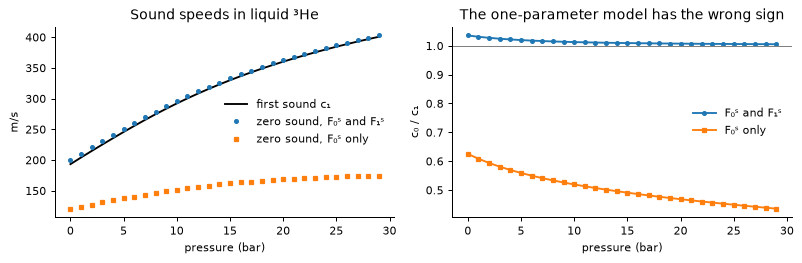

In [3]:
sys.path.insert(0, str(ROOT / "verification/he3_landau"))
import zero_sound_real_he3 as Z   # w(s) and a bisection root finder
mp.mp.dps = 30
P_, c0a, c0b, c1 = [], [], [], []
for d in rows:
    F0, F1, vF = mp.mpf(d["F0s"]), 3 * (mp.mpf(d["m_star_over_m"]) - 1), d["v_F_m_per_s"]
    sa = Z.root(lambda s: Z.w(s) - 1 / F0)
    sb = Z.root(lambda s: Z.w(s) - 1 / (F0 + F1 * s**2 / (1 + F1 / 3)))
    P_.append(d["P_bar"]); c0a.append(float(sa) * vF); c0b.append(float(sb) * vF)
    c1.append(float(vF * mp.sqrt((1 + F0) * (1 + F1 / 3) / 3)))
c0a, c0b, c1 = map(np.array, (c0a, c0b, c1))
print("F0 only:  c0 < c1 at every pressure:", bool(np.all(c0a < c1)))
print("F0, F1:   c0 > c1 at every pressure:", bool(np.all(c0b > c1)))
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(P_, c1, "k-", label="first sound c₁")
ax[0].plot(P_, c0b, "o", ms=3, label="zero sound, F₀ˢ and F₁ˢ")
ax[0].plot(P_, c0a, "s", ms=3, label="zero sound, F₀ˢ only")
ax[0].set(xlabel="pressure (bar)", ylabel="m/s", title="Sound speeds in liquid ³He"); ax[0].legend(frameon=False)
ax[1].plot(P_, c0b / c1, "o-", ms=3, label="F₀ˢ and F₁ˢ")
ax[1].plot(P_, c0a / c1, "s-", ms=3, label="F₀ˢ only")
ax[1].axhline(1, color="grey", lw=0.8)
ax[1].set(xlabel="pressure (bar)", ylabel="c₀ / c₁", title="The one-parameter model has the wrong sign"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## The exact solver with $F_1^s$

With $u=1/s^2$, $a = 1+F_1^s/3$ and $\chi\approx P/Q$, the dispersion relation becomes the polynomial
$P(u)(F_0^s a u + F_1^s) - Q(u)\,a u = 0$ over $\mathbb{Q}$. The inputs are turned into exact rationals first.

In [4]:
from agora_swarm.agents.linear_response import LinearResponseStage
from agora_swarm.agents.kinetic import KineticStage
with quiet():
    kernel = LinearResponseStage().landau_zero_sound_kernel(order=10)
    r = KineticStage().solve_zero_sound_root_f0_f1(kernel, sp.Rational("10.2788"), sp.Rational("5.2601"), M=3)
print("0 bar, [3/3]:  u is the root of", sp.factor(sp.sympify(r["dispersion_polynomial"])))
print("               u =", r["u_exact"])
print("               s =", r["s_numeric"][:16])

0 bar, [3/3]:  u is the root of u*(2309762924693*u**3 - 12681454807554*u**2 + 13627433496985*u - 1126125000000)/1126125000000
               u = CRootOf(2309762924693*x**3 - 12681454807554*x**2 + 13627433496985*x - 1126125000000, 0)
               s = 3.33220988935662


## The pressure sweep

`simulations/large_scale/he3_pressure_sweep.py` runs this for 8 pressures × $M = 1..6$ and compares each exact root with
a 60-digit reference. Here is a smaller live run, followed by the stored full result.

In [5]:
sys.path.insert(0, str(ROOT / "simulations/large_scale"))
import he3_pressure_sweep as S
with quiet():
    live = [r for r in S.sweep(max_order=4) if r["P_bar"] in (0, 15, 29)]
for r in live:
    print(f"P = {r['P_bar']:2d} bar: " + "  ".join(f"M{o['M']} {o['rel_error']:.1e}" for o in r["orders"]))
stored = json.loads((ROOT / "alexandrie_data/SIMULATIONS/he3_pressure_sweep.json").read_text())
print(f"\nstored full sweep: worst error at M = 6 is {stored['worst_rel_error_top_order']:.1e}; "
      f"strictly decreasing in M: {stored['error_strictly_decreasing_in_M']}")

P =  0 bar: M1 8.0e-04  M2 4.6e-07  M3 2.6e-10  M4 1.4e-13
P = 15 bar: M1 3.8e-05  M2 6.6e-10  M3 1.1e-14  M4 1.9e-19
P = 29 bar: M1 1.0e-05  M2 3.6e-11  M3 1.3e-16  M4 4.4e-22

stored full sweep: worst error at M = 6 is 4.5e-20; strictly decreasing in M: True


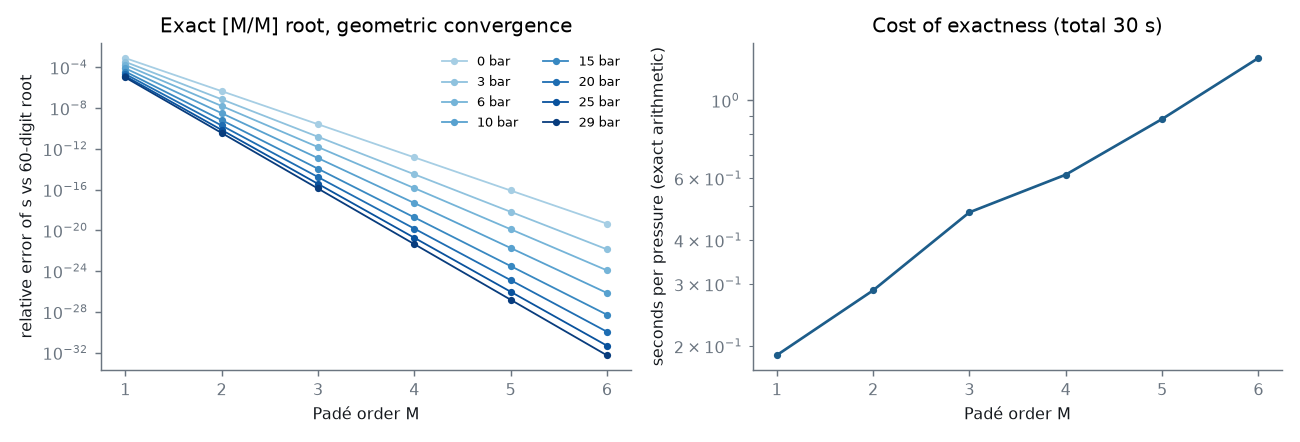

In [6]:
from IPython.display import Image
Image(filename=str(ROOT / "docs/figures/simulations/he3_pressure_sweep.png"), width=760)

**Caveat.** At 0 bar the absolute $c_1 = 193$ m/s is about 5% above the commonly quoted measurement. The source notes
that its compressibility is least certain below about 2 bar. The *ratio* $c_0/c_1$ is the robust result.